# Task 3: Heart Disease Prediction 
**Objective:**<br>
 Build a model to predict whether a person is at risk of heart disease based on their health data. <br>
**Dataset:** <br>
 Heart Disease UCI Dataset (available on Kaggle) <br>
**Instructions:** <br>
● Clean the dataset (handle missing values if any). <br>
● Perform Exploratory Data Analysis (EDA) to understand trends. <br>
● Train a classification model (Logistic Regression or Decision Tree). <br>
● Evaluate using metrics: accuracy, ROC curve, and confusion matrix. <br>
● Highlight important features affecting prediction. <br>
**Skills:** <br>
● Binary classification <br>
● Medical data understanding and interpretation<br> 
● Model evaluation using ROC-AUC and confusion matrix<br> 
● Feature importance analysis<br>

# Import libraries

In [84]:
import pandas as pd

In [85]:
import numpy as np

In [86]:
import matplotlib.pyplot as plt

In [87]:
import seaborn as sns

# Load Dataset 

In [88]:
df = pd.read_csv("heart.csv")

In [89]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [90]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [92]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [93]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [94]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [95]:
df.shape

(918, 12)

### RestingBP and Cholesterol have some zeros values so we replace these zero valuse with maen



In [96]:
df["RestingBP"].describe()

count    918.000000
mean     132.396514
std       18.514154
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: RestingBP, dtype: float64

In [98]:
df["RestingBP"].replace(0, np.nan, inplace=True)
df["RestingBP"].fillna(df["RestingBP"].median(), inplace=True)

In [99]:
df["RestingBP"].describe()

count    918.000000
mean     132.538126
std       17.990127
min       80.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: RestingBP, dtype: float64

In [100]:
df["Cholesterol"].describe()

count    918.000000
mean     198.799564
std      109.384145
min        0.000000
25%      173.250000
50%      223.000000
75%      267.000000
max      603.000000
Name: Cholesterol, dtype: float64

In [101]:
mean = np.mean(df["Cholesterol"]) 
mean

np.float64(198.7995642701525)

In [102]:
df["Cholesterol"] = df["Cholesterol"].replace(0, mean)

In [103]:
df["Cholesterol"].describe()

count    918.000000
mean     236.047413
std       56.240952
min       85.000000
25%      198.799564
50%      223.000000
75%      267.000000
max      603.000000
Name: Cholesterol, dtype: float64

In [104]:
# Important feacture 
# Age
# Sex
# RestingBP
# Cholesterol
# RestingECG
# ExerciseAngina
# ST_Slope

# Visulaing and Relationship between data 

<Axes: xlabel='Age', ylabel='Count'>

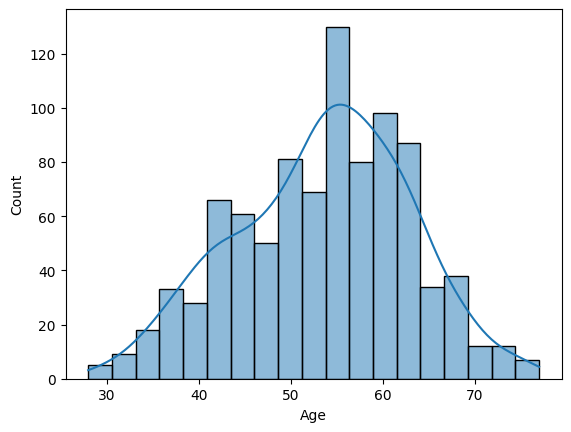

In [120]:
sns.histplot(df['Age'], kde=True)

<Axes: xlabel='RestingBP', ylabel='Count'>

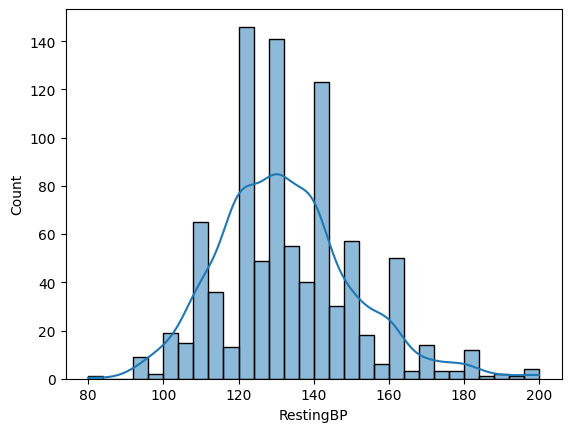

In [121]:
sns.histplot(df["RestingBP"] , kde=True)

<Axes: xlabel='Cholesterol', ylabel='Count'>

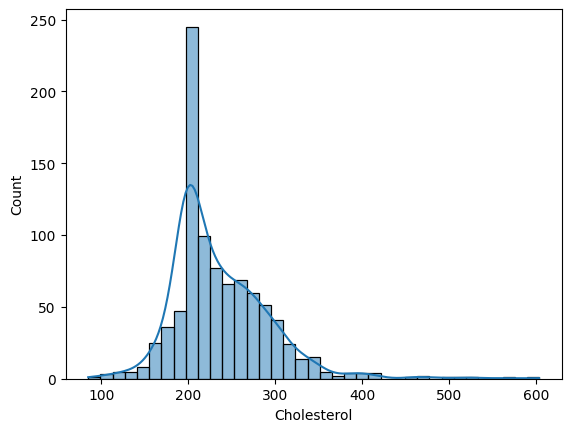

In [122]:
sns.histplot(df["Cholesterol"] , kde=True)

<Axes: xlabel='RestingBP'>

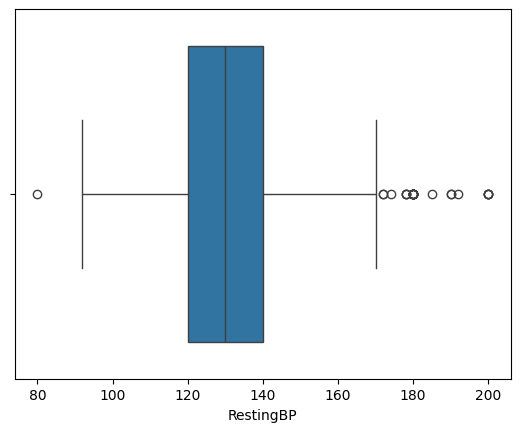

In [123]:
sns.boxplot(x=df['RestingBP'])

<Axes: xlabel='Sex', ylabel='count'>

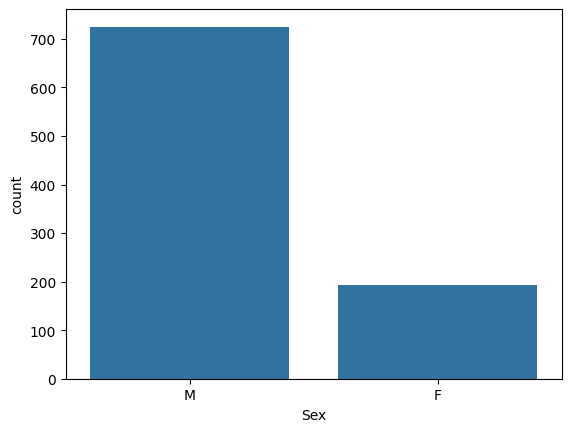

In [124]:
sns.countplot(x='Sex', data=df)

<Axes: xlabel='ChestPainType', ylabel='count'>

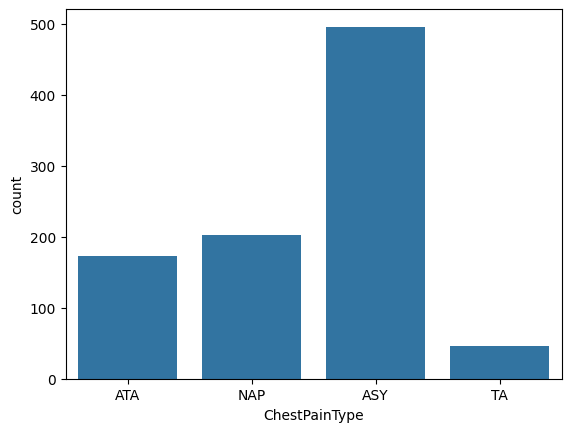

In [125]:
sns.countplot(x='ChestPainType', data=df)

<Axes: xlabel='ExerciseAngina', ylabel='count'>

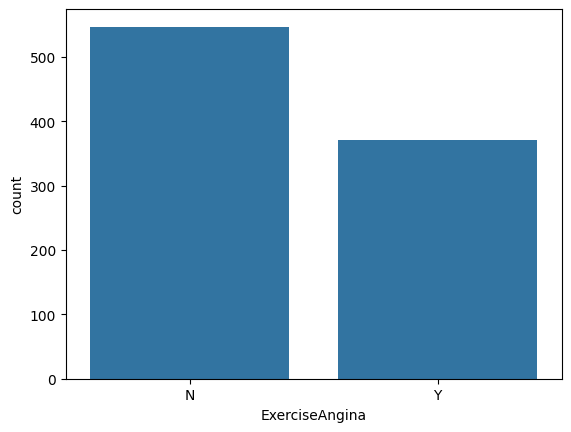

In [126]:
sns.countplot(x='ExerciseAngina', data=df)

<Axes: xlabel='HeartDisease', ylabel='count'>

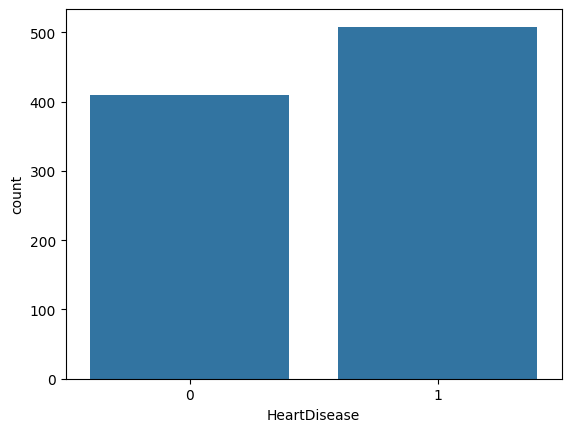

In [127]:
sns.countplot(x='HeartDisease', data=df)

<Axes: xlabel='ST_Slope', ylabel='count'>

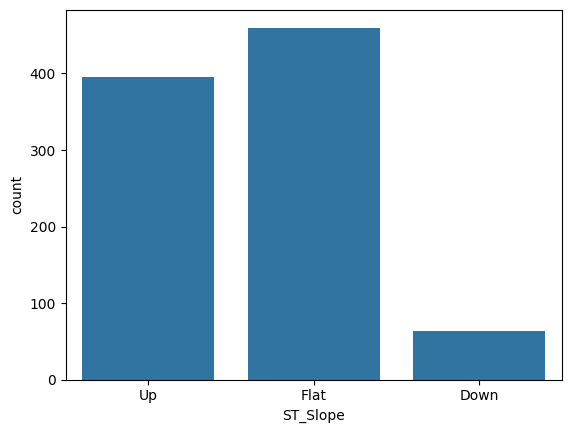

In [22]:
sns.countplot(x='ST_Slope', data=df)

<Axes: xlabel='Sex', ylabel='count'>

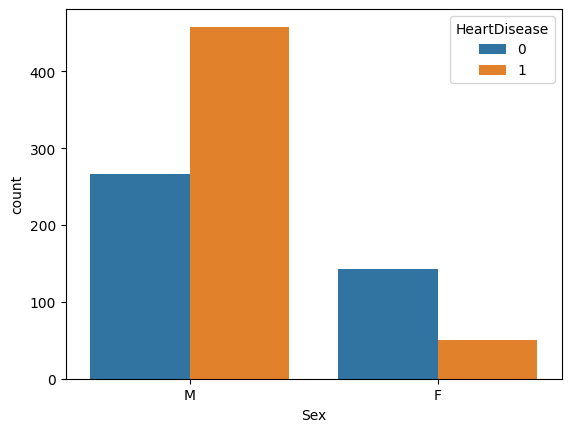

In [23]:
sns.countplot(x='Sex', hue='HeartDisease', data=df)

<Axes: xlabel='ChestPainType', ylabel='count'>

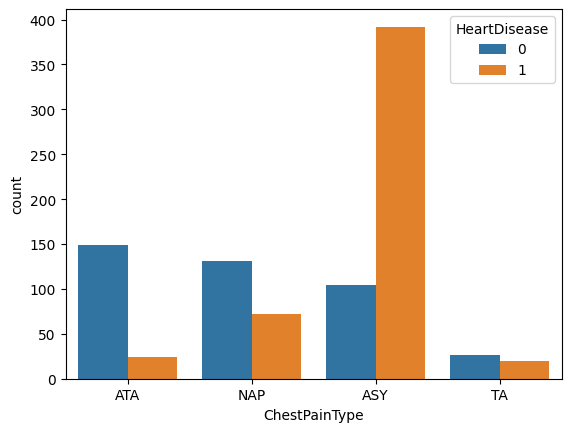

In [24]:
sns.countplot(x='ChestPainType', hue='HeartDisease', data=df)

<Axes: xlabel='ExerciseAngina', ylabel='count'>

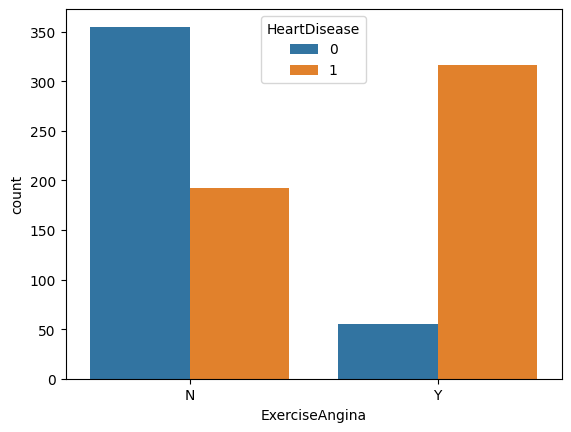

In [25]:
sns.countplot(x='ExerciseAngina', hue='HeartDisease', data=df)

<Axes: xlabel='ST_Slope', ylabel='count'>

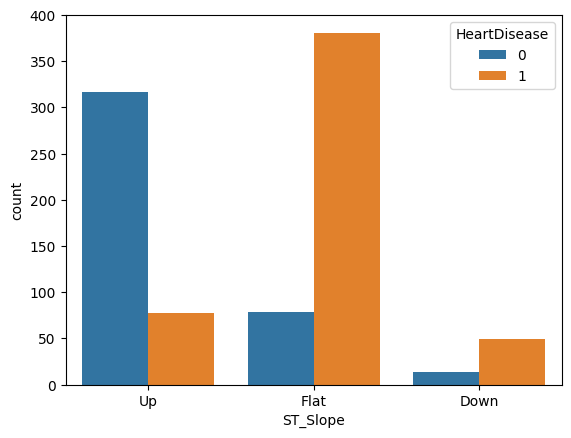

In [26]:
sns.countplot(x='ST_Slope', hue='HeartDisease', data=df)

<Axes: xlabel='FastingBS', ylabel='count'>

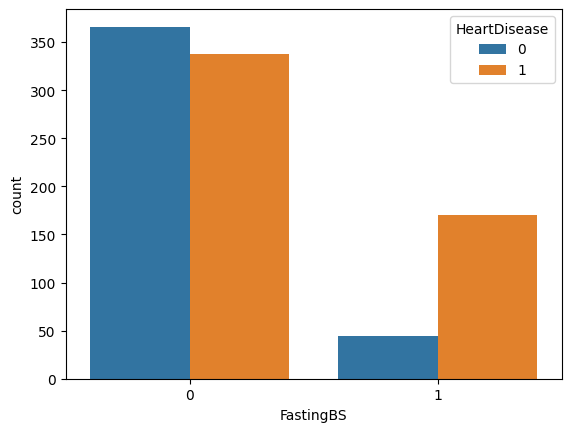

In [27]:
sns.countplot(x='FastingBS', hue='HeartDisease', data=df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

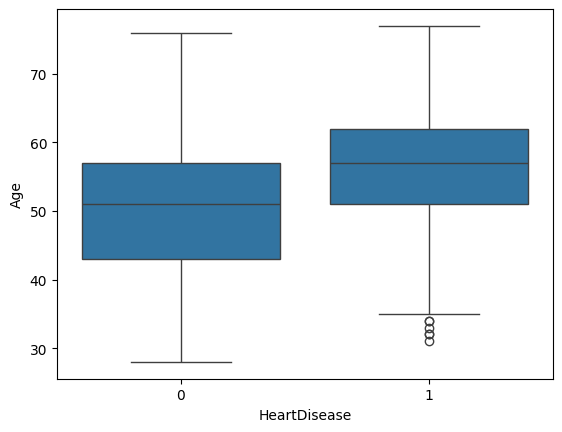

In [28]:
sns.boxplot(x='HeartDisease', y='Age', data=df)

<Axes: xlabel='HeartDisease', ylabel='RestingBP'>

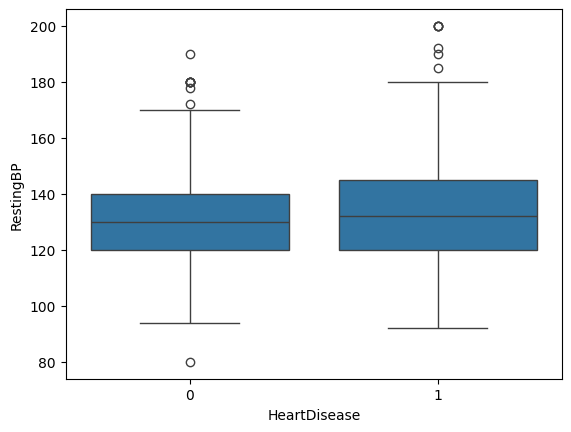

In [29]:
sns.boxplot(x='HeartDisease', y='RestingBP', data=df)

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

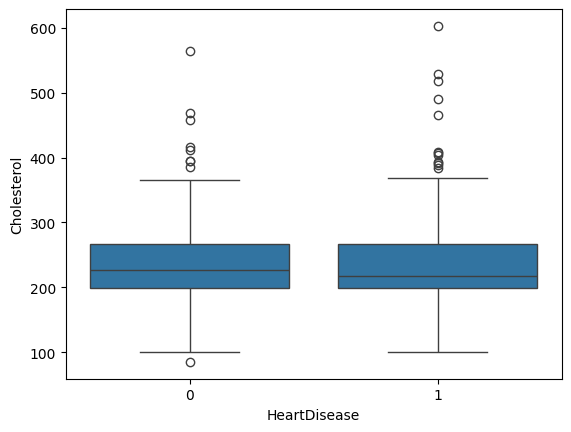

In [30]:
sns.boxplot(x='HeartDisease', y='Cholesterol', data=df)

<Axes: xlabel='HeartDisease', ylabel='MaxHR'>

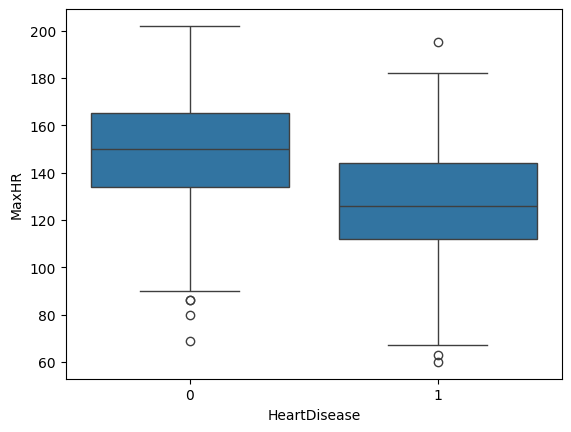

In [31]:
sns.boxplot(x='HeartDisease', y='MaxHR', data=df)

<Axes: xlabel='HeartDisease', ylabel='Oldpeak'>

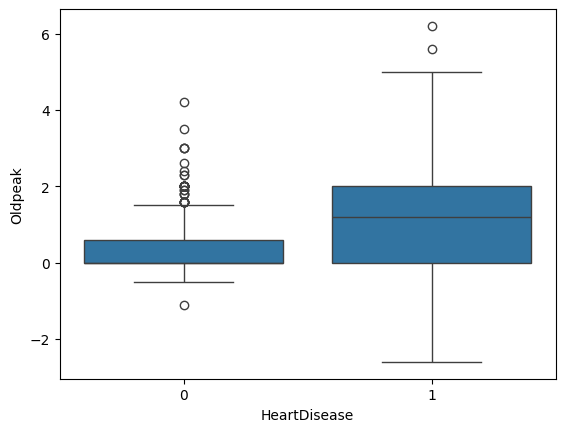

In [32]:
sns.boxplot(x='HeartDisease', y='Oldpeak', data=df)

<Axes: xlabel='Age', ylabel='Cholesterol'>

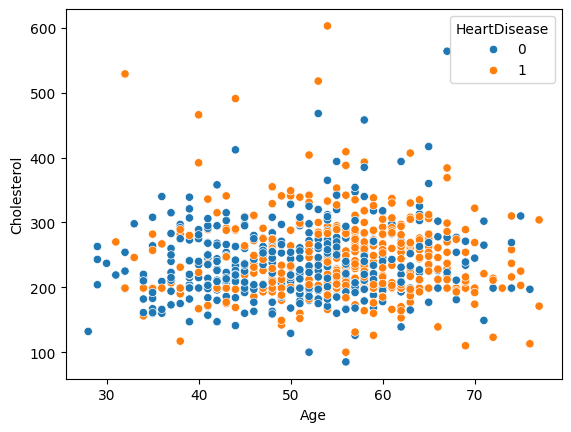

In [33]:
sns.scatterplot(x='Age', y='Cholesterol', hue='HeartDisease', data=df)

<Axes: xlabel='Age', ylabel='MaxHR'>

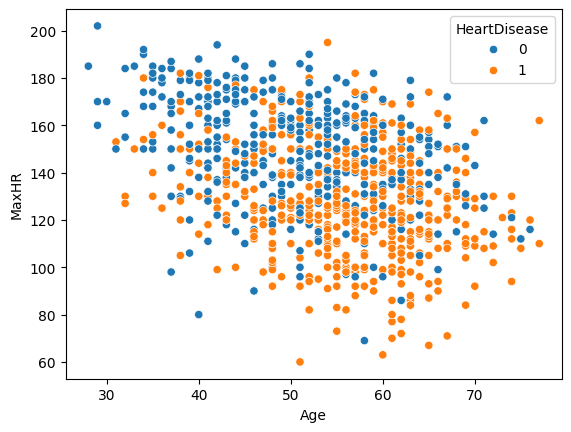

In [34]:
sns.scatterplot(x='Age', y='MaxHR', hue='HeartDisease', data=df)

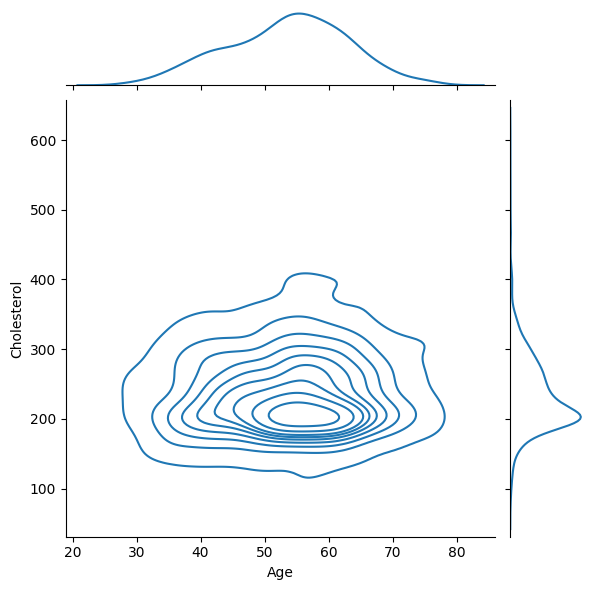

In [35]:
sns.jointplot(x='Age', y='Cholesterol', kind='kde', data=df)

<Axes: >

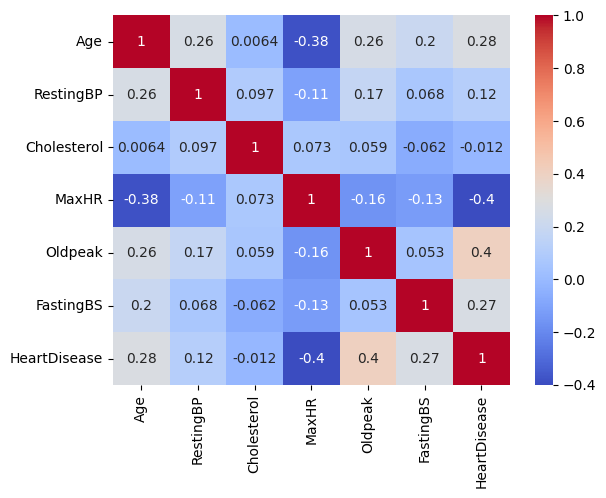

In [36]:
num_cols = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak','FastingBS','HeartDisease']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')

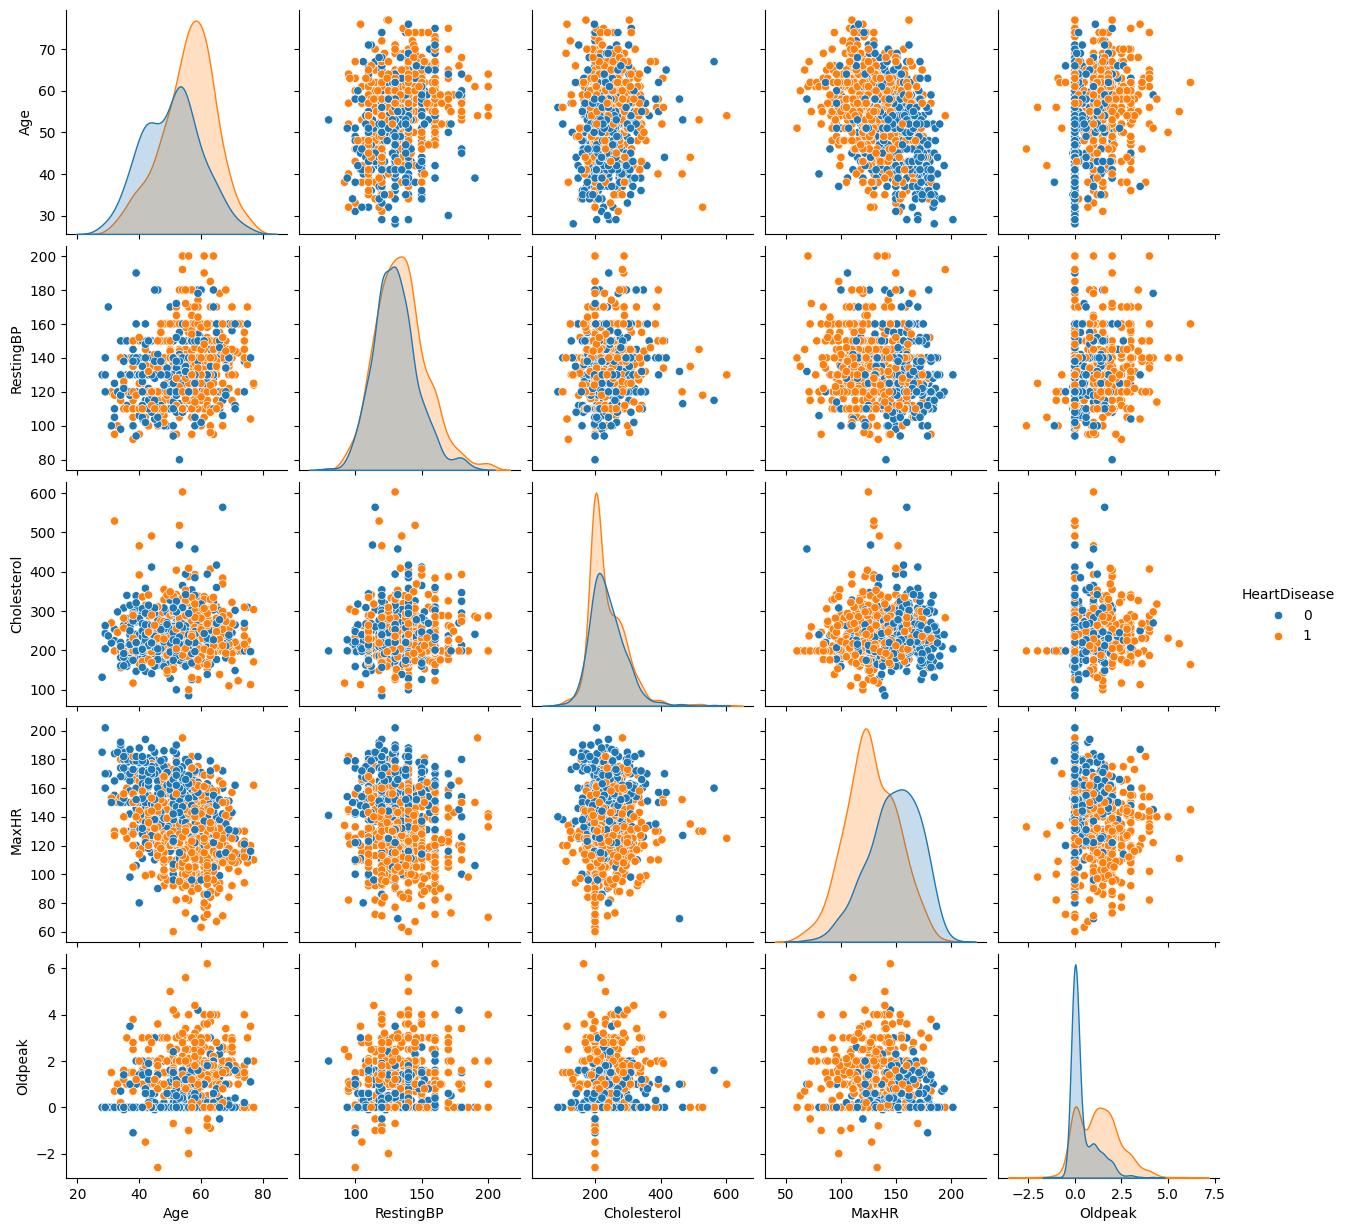

In [37]:
sns.pairplot(df[['Age','RestingBP','Cholesterol','MaxHR','Oldpeak','HeartDisease']], hue='HeartDisease')

# Label Encoding the columns:

- Sex
- ChestPainType
- RestingECG
- ExerciseAngina
- ST_Slope

In [116]:
from sklearn.preprocessing import LabelEncoder

In [117]:
label_encoders = {}
for col in ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [118]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140.0,289.0,0,1,172,0,0.0,2,0
1,49,0,2,160.0,180.0,0,1,156,0,1.0,1,1
2,37,1,1,130.0,283.0,0,2,98,0,0.0,2,0
3,48,0,0,138.0,214.0,0,1,108,1,1.5,1,1
4,54,1,2,150.0,195.0,0,1,122,0,0.0,2,0


In [119]:
label_encoders

{'Sex': LabelEncoder(),
 'ChestPainType': LabelEncoder(),
 'RestingECG': LabelEncoder(),
 'ExerciseAngina': LabelEncoder(),
 'ST_Slope': LabelEncoder()}

# Split independent and dependent feacture

In [120]:
from sklearn.model_selection import train_test_split

In [121]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140.0,289.0,0,1,172,0,0.0,2,0
1,49,0,2,160.0,180.0,0,1,156,0,1.0,1,1
2,37,1,1,130.0,283.0,0,2,98,0,0.0,2,0
3,48,0,0,138.0,214.0,0,1,108,1,1.5,1,1
4,54,1,2,150.0,195.0,0,1,122,0,0.0,2,0


In [122]:
cols = ["Age","Sex","ChestPainType","RestingBP", "Cholesterol","RestingECG","ExerciseAngina", "ST_Slope"]
X = df[cols]
X

,Age,Sex,ChestPainType,RestingBP,Cholesterol,RestingECG,ExerciseAngina,ST_Slope
0,40,1,1,140.0,289.0,1,0,2
1,49,0,2,160.0,180.0,1,0,1
2,37,1,1,130.0,283.0,2,0,2
3,48,0,0,138.0,214.0,1,1,1
4,54,1,2,150.0,195.0,1,0,2
...,...,...,...,...,...,...,...,...
913,45,1,3,110.0,264.0,1,0,1
914,68,1,0,144.0,193.0,1,0,1
915,57,1,0,130.0,131.0,1,1,1
916,57,0,1,130.0,236.0,0,0,1


In [123]:
y = df["HeartDisease"]
y

0      0
1      1
2      0
3      1
4      0
      ..
913    1
914    1
915    1
916    1
917    0
Name: HeartDisease, Length: 918, dtype: int64

In [124]:
X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size = 0.20 , random_state=40
)

# Load Decision tree model

In [125]:
from sklearn.tree import DecisionTreeClassifier

In [126]:
model = DecisionTreeClassifier()

In [127]:
parameters = {
    "criterion" : ["gini" , "entropy" , "log_loss"],
    "ccp_alpha":[0.01 , 0.001,0.03],
    "splitter" : ["best" , "random"], 
    "max_depth" : [1,2,3,4,5,6,7,9,10,15,20,30],
    "max_features": [None, "sqrt", "log2"]
}

In [128]:
from sklearn.model_selection import GridSearchCV

In [129]:
cv = GridSearchCV(model , param_grid=parameters , cv=5, scoring="accuracy")

In [130]:
cv.fit(X_train , y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'ccp_alpha': [0.01, 0.001, ...], 'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 2, ...], 'max_features': [None, 'sqrt', ...], ...}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [131]:
cv.best_params_

{'ccp_alpha': 0.001,
 'criterion': 'gini',
 'max_depth': 4,
 'max_features': None,
 'splitter': 'random'}

In [132]:
cv.best_score_

np.float64(0.8392973627807286)

# Evaluate using metrics: accuracy, ROC curve, and confusion matrix.

#### Accuracy at Training data

In [133]:
from sklearn.metrics import accuracy_score , roc_curve , roc_auc_score, confusion_matrix , classification_report

In [134]:
y_pred = cv.predict(X_train)

In [135]:
score = accuracy_score(y_pred , y_train)

In [136]:
print("Accuracy Score of training data  : ", score)

Accuracy Score of training data  :  0.8079019073569482


#### Accuracy at test data

In [137]:
y_pred = cv.predict(X_test)

In [138]:
score = accuracy_score(y_pred , y_test)

In [139]:
print("Accuracy Score of testing data  : ", score)

Accuracy Score of testing data  :  0.8586956521739131


### Since the trainig accuracy and test accuracy is very close that mean model is genralize.Model not underfit and not overfit.

# Find the ROC Score

In [141]:
# Predict probabilities for positive class (1)
y_proba = cv.predict_proba(X_test)[:, 1]

In [142]:
# ROC points
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

In [143]:
roc_auc_score(y_test, y_proba)

0.8937003058103975

In [144]:
auc_score = roc_auc_score(y_test, y_proba)

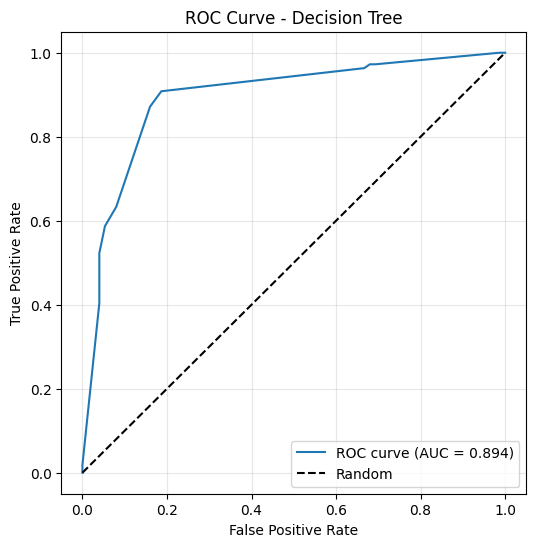

In [145]:
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


# confusion matrix and classification_report

In [146]:
confusion_matrix(y_test , y_pred)

array([[63, 12],
       [14, 95]])

In [147]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83        75
           1       0.89      0.87      0.88       109

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.86      0.86       184



# Final Report

In this project, a Decision Tree Classification model was developed to predict the risk of heart disease using the UCI Heart Disease dataset.

The dataset was first cleaned by handling zero values in important features such as Resting Blood Pressure and Cholesterol. Exploratory Data Analysis (EDA) was performed using various visualizations including histograms, count plots, boxplots, and correlation heatmaps to understand relationships between features.

Categorical variables were encoded using Label Encoding, and relevant features were selected for model training. The dataset was split into training and testing sets using an 80-20 ratio.

A Decision Tree model was trained and optimized using GridSearchCV to find the best hyperparameters. The best model achieved an accuracy of approximately 85% on test data, indicating good generalization.

Model performance was further evaluated using ROC-AUC score, which was 0.884, showing strong classification ability. The confusion matrix and classification report confirmed balanced performance across both classes.

**Overall,** the model successfully predicts heart disease risk with good accuracy and reliability.